<a href="https://colab.research.google.com/github/mohand22yehia-commits/telecome_egypt_assigment/blob/main/WE_ML_Smart_Plan_Recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/0/0f/We_logo.svg/3840px-We_logo.svg.png" alt="WE Logo" width="60" style="margin-bottom:8px"/>

# Telecom Egypt (WE) — ML Project
## Smart Plan Recommendation System

---

### Background

Telecom Egypt (WE) serves thousands of subscribers across Egypt with internet plans that vary in speed, quota, and price. A key business challenge is **plan-subscriber mismatch** — subscribers enrolled in plans that do not reflect their actual usage and payment behavior.

This project simulates a real-world data science task at WE. You are part of the Data & AI team. Your mission is to build a machine learning model that analyzes subscriber profiles and recommends the most suitable plan action:

> **Upgrade** — the subscriber needs a bigger plan  
> **Downgrade** — the subscriber is over-paying for what they use  
> **Keep** — the current plan is a good fit

---

### Available Datasets

| Dataset | Description |
|---------|-------------|
| `Customer.csv` | Subscriber demographics and plan enrollment |
| `Subscription_Plan_Lkp.csv` | Plan details — quota, speed, and price |
| `Network_Elements.csv` | Infrastructure type per subscriber (VDSL, FTTH, etc.) |
| `Payments.csv` | Monthly payment transactions per subscriber |
| `Consumption_RG_LKP.csv` | Lookup table for consumption rating groups |

---

### General Instructions

- Read each step carefully before writing any code.
- Each step has a clear objective — understand **why** you are doing it, not just **how**.
- You are expected to make decisions along the way. Document your reasoning in markdown cells.
- There is no single correct answer — justify your choices.


---
## Step 1 — Load & Explore the Data

### Objective
Understand what data you have before touching it.

### Why This Step Matters
Before building any model, a data scientist must fully understand the data — its structure, quality, and distributions. Skipping EDA leads to wrong assumptions and poor models.

### What To Do
- Load all 5 datasets and print their shape and data types.
- Check for missing values in each table and decide how to handle them.
- Visualize key distributions:
  - `Customer`: `SUBSCRIBER_STATUS`, `CUSTOMER_CLASS`, `GENDER`
  - `Subscription_Plan_Lkp`: price range, speed range, quota sizes
  - `Payments`: revenue columns and monthly revenue trend
  - `Network_Elements`: breakdown of `TECHNOLOGY_TYPE`

**Expected Output:** At least 4 visualizations. Write a short observation below each one explaining what you see.


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')


In [60]:
import pandas as pd
customer = pd.read_csv("/content/Customer.csv")
plans = pd.read_csv("/content/Subscription_Plan_Lkp.csv")
payments = pd.read_csv("/content/Payments.csv")
network = pd.read_csv("/content/Network_Elements.csv")
consumption = pd.read_csv("/content/Consumption_RG_LKP.csv")

In [61]:
datasets = {
    "Customer": customer,
    "Plans": plans,
    "Payments": payments,
    "Network": network,
    "Consumption": consumption
}
print("Checking for missing values in each dataset:")
for name, df in datasets.items():
    print(f"\n--- {name} ---")
    missing_values = df.isnull().sum()
    if missing_values.sum() == 0:
        print("No missing values.")
    else:
        print(missing_values[missing_values > 0])


Checking for missing values in each dataset:

--- Customer ---
GROUP_ID#    9320
BIRTHDATE      61
dtype: int64

--- Plans ---
No missing values.

--- Payments ---
No missing values.

--- Network ---
CENTRAL_NAME    30
dtype: int64

--- Consumption ---
No missing values.


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=customer, x='SUBSCRIBER_STATUS', palette='viridis')
plt.title('Distribution of Subscriber Status')
plt.xlabel('Subscriber Status')
plt.ylabel('Count')
plt.show()

# Observation: The majority of subscribers are 'Active'. There are significantly fewer 'Suspended' and 'Churned' subscribers.

# Visualize CUSTOMER_CLASS
plt.figure(figsize=(10, 6))
sns.countplot(data=customer, x='CUSTOMER_CLASS', palette='magma')
plt.title('Distribution of Customer Class')
plt.xlabel('Customer Class')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Observation: 'Residential' customers form the largest segment, followed by 'SOHO Small Office/Home Office' and 'Business' customers.

# Visualize GENDER
plt.figure(figsize=(6, 6))
customer['GENDER'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of Gender')
plt.ylabel('') # Hide the default 'GENDER' label for pie chart
plt.show()



Plans Columns: ['SUBSCRIPTION_PLAN_ID#', 'SUBSCRIPTION_PLAN_FAMILY_ID#', 'SUBSCRIPTION_PLAN_DESC', 'SUBSCRIPTION_PLAN_FAMILY_DESC', 'QUOTA', 'SPEED', 'PRICE_PLAN_PRICE', 'SUBSCRIPTION_PLAN_START_TIME', 'SUBSCRIPTION_PLAN_END_TIME', 'SUBSCRIPTION_PLAN_FAMILY_START_TIME', 'SUBSCRIPTION_PLAN_FAMILY_END_TIME']


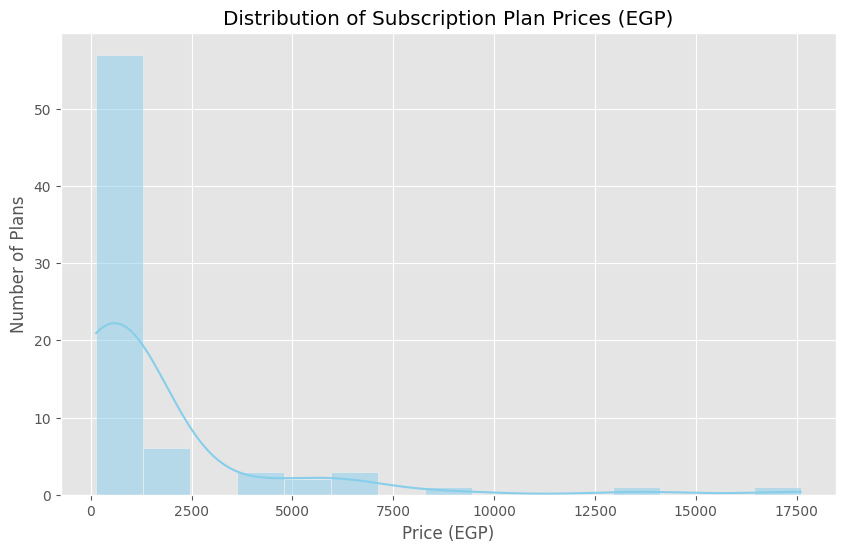

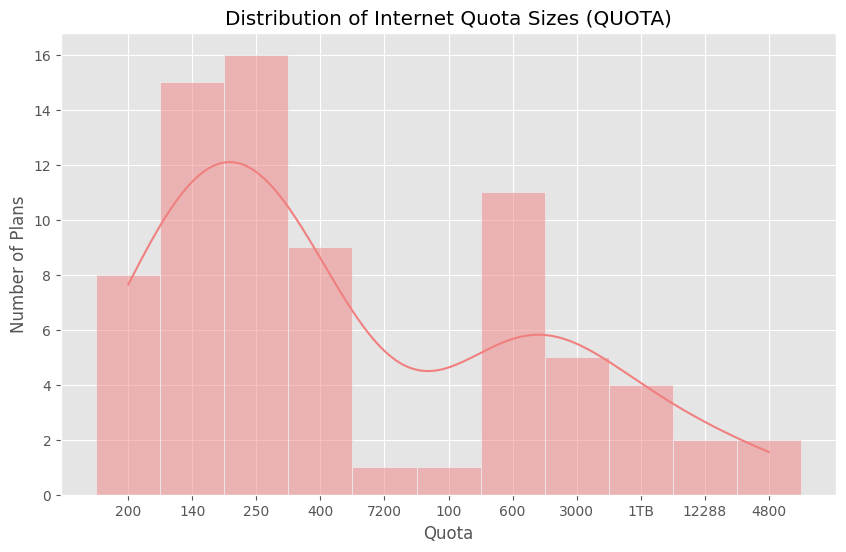

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Plans Columns:", plans.columns.tolist())
quota_col = "QUOTA" if "QUOTA" in plans.columns else "QUOTA_NUM"

active_plans = plans[plans["PRICE_PLAN_PRICE"] > 0]

plt.figure(figsize=(10, 6))
sns.histplot(active_plans["PRICE_PLAN_PRICE"], bins=15, kde=True, color="skyblue")
plt.title("Distribution of Subscription Plan Prices (EGP)")
plt.xlabel("Price (EGP)")
plt.ylabel("Number of Plans")
plt.show()

if quota_col in active_plans.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(active_plans[quota_col], bins=15, kde=True, color="lightcoral")
    plt.title(f"Distribution of Internet Quota Sizes ({quota_col})")
    plt.xlabel("Quota")
    plt.ylabel("Number of Plans")
    plt.show()
else:
    print(f"Error: Neither 'QUOTA' nor 'QUOTA_NUM' found in plans columns.")


Payments Columns: ['Payment_ID', 'CONNECT_DATE', 'SUBSCRIBER_ID#', 'RENT_REVENUE', 'OUT_BUNDLE_REVENUE', 'CREATION_FEES_REVENUE', 'DEVICES_REVENUE', 'IN_BUNDLE_REVENUE', 'ADDON_REVENUE', 'TAX_AMOUNT']


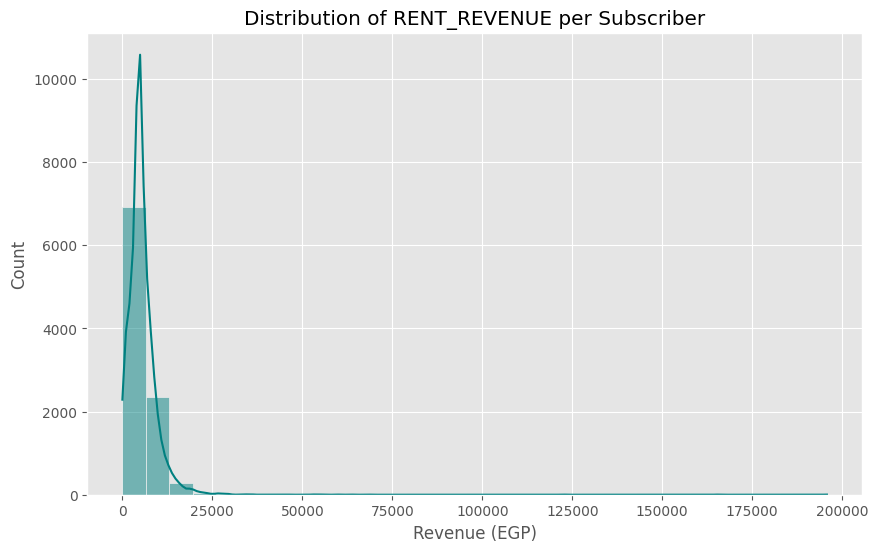

/tmp/ipykernel_24190/2477446723.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_rev = payments.set_index("CONNECT_DATE").resample("M")[pay_col].sum()


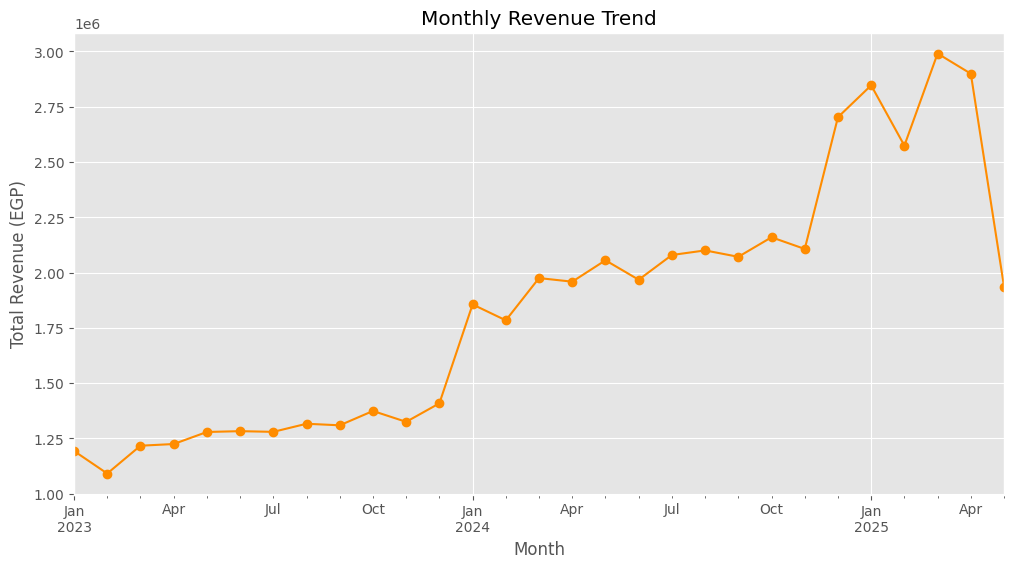

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Payments Columns:", payments.columns.tolist())

pay_col = "TOTAL_PAYMENT" if "TOTAL_PAYMENT" in payments.columns else "RENT_REVENUE"

sub_revenue = payments.groupby("SUBSCRIBER_ID#")[pay_col].sum()

plt.figure(figsize=(10, 6))
sns.histplot(sub_revenue, bins=30, kde=True, color="teal")
plt.title(f"Distribution of {pay_col} per Subscriber")
plt.xlabel("Revenue (EGP)")
plt.ylabel("Count")
plt.show()
payments["CONNECT_DATE"] = pd.to_datetime(payments["CONNECT_DATE"])
monthly_rev = payments.set_index("CONNECT_DATE").resample("M")[pay_col].sum()

plt.figure(figsize=(12, 6))
monthly_rev.plot(marker="o", color="darkorange")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue (EGP)")
plt.grid(True)
plt.show()

---
## Step 2 — Join the Tables

### Objective
Build a single unified subscriber profile by merging all relevant tables.

### Why This Step Matters
Real-world data is never in one place. The ability to correctly join tables — using the right keys and avoiding duplicates or row explosions — is a core data engineering skill.

### What To Do
- Start from `Customer.csv` as the base table.
- Join `Subscription_Plan_Lkp` on `SUBSCRIPTION_PLAN_ID#` → adds quota, speed, price.
- Join `Network_Elements` on `SERVICE_NUMBER#` → adds technology type.
- Aggregate `Payments` per subscriber, then join on `SUBSCRIBER_ID#`.
- After each join, verify the row count has not changed unexpectedly.

> **Watch out for:** Duplicate plan IDs in the lookup table — handle them before joining to avoid inflating your row count.


In [64]:

print(f"Shape of plans DataFrame before cleaning: {plans.shape}")
duplicate_plan_ids = plans['SUBSCRIPTION_PLAN_ID#'].duplicated().sum()
print(f"Number of duplicate plan IDs found: {duplicate_plan_ids}")

plans_cleaned = plans.sort_values(by=['SUBSCRIPTION_PLAN_ID#', 'SUBSCRIPTION_PLAN_END_TIME'], ascending=[True, False])\
                       .drop_duplicates(subset=['SUBSCRIPTION_PLAN_ID#'], keep='first')

print(f"Shape of plans DataFrame after cleaning: {plans_cleaned.shape}")

Shape of plans DataFrame before cleaning: (108, 11)
Number of duplicate plan IDs found: 0
Shape of plans DataFrame after cleaning: (108, 11)


In [65]:

print(f"Shape of customer DataFrame before joining plans: {customer.shape}")

customer = pd.merge(customer, plans_cleaned, on='SUBSCRIPTION_PLAN_ID#', how='left')

print(f"Shape of customer DataFrame after joining plans: {customer.shape}")

Shape of customer DataFrame before joining plans: (9995, 17)
Shape of customer DataFrame after joining plans: (9995, 27)


In [66]:

print(f"Shape of customer DataFrame before joining network: {customer.shape}")

customer = pd.merge(customer, network, on='SERVICE_NUMBER#', how='left')

print(f"Shape of customer DataFrame after joining network: {customer.shape}")

Shape of customer DataFrame before joining network: (9995, 27)
Shape of customer DataFrame after joining network: (9995, 34)


In [67]:

payments['CONNECT_DATE'] = pd.to_datetime(payments['CONNECT_DATE'])
revenue_cols = ['RENT_REVENUE', 'OUT_BUNDLE_REVENUE', 'CREATION_FEES_REVENUE',
                'DEVICES_REVENUE', 'IN_BUNDLE_REVENUE', 'ADDON_REVENUE', 'TAX_AMOUNT']
payments['total_transaction_amount'] = payments[revenue_cols].sum(axis=1)
payments_agg = payments.groupby('SUBSCRIBER_ID#').agg(
    total_revenue=('total_transaction_amount', 'sum'),
    addon_total=('ADDON_REVENUE', 'sum'),
    num_unique_months=('CONNECT_DATE', lambda x: x.dt.to_period('M').nunique())
).reset_index()
payments_agg['num_unique_months'] = payments_agg['num_unique_months'].replace(0, 1)
payments_agg['avg_monthly_rev'] = payments_agg['total_revenue'] / payments_agg['num_unique_months']

payments_to_join = payments_agg[['SUBSCRIBER_ID#', 'total_revenue', 'addon_total', 'avg_monthly_rev']]
print(f"Shape of customer DataFrame before joining payments: {customer.shape}")
customer = pd.merge(customer, payments_to_join, on='SUBSCRIBER_ID#', how='left')
print(f"Shape of customer DataFrame after joining payments: {customer.shape}")

Shape of customer DataFrame before joining payments: (9995, 34)
Shape of customer DataFrame after joining payments: (9995, 37)


---
## Step 3 — Feature Engineering

### Objective
Transform raw columns into meaningful features that help the model learn patterns.

### Why This Step Matters
Raw data rarely goes directly into a model. Feature engineering is where domain knowledge meets data science — the better your features, the better your model.

### Features To Create

| Feature | Formula | What It Captures |
|---------|---------|-----------------|
| `tenure_days` | `reference_date − ACTIVATION_DATE` | How long the subscriber has been active |
| `avg_monthly_rev` | Mean of payments per subscriber | Average spending per month |
| `addon_ratio` | `addon_total / total_revenue` | How often the subscriber exceeds their bundle |
| `price_to_quota_ratio` | `PRICE_PLAN_PRICE / QUOTA_NUM` | Cost per GB — how expensive the plan is relative to its size |

---

**Formula Details:**

**addon_ratio:**

$$\text{addon_ratio} = \frac{\text{ADDON_REVENUE}}{\text{total_revenue}}$$

*Example:* Subscriber paid 500 EGP total, 100 EGP was addon → addon_ratio = 100/500 = **0.20** (20% outside bundle)

---

**price_to_quota_ratio:**

$$\text{price_to_quota_ratio} = \frac{\text{PRICE_PLAN_PRICE}}{\text{QUOTA_NUM}}$$

*Example:* Plan costs 570 EGP for 400 GB → price_to_quota_ratio = 570/400 = **1.43 EGP per GB**

---

After creating each feature, print a `.describe()` and check for outliers or unexpected values.


In [68]:
import pandas as pd
if 'ACTIVATION_DATE' in customer.columns and 'payments' in locals():
    customer['ACTIVATION_DATE'] = pd.to_datetime(customer['ACTIVATION_DATE'])
    reference_date = pd.to_datetime(payments['CONNECT_DATE'].max())
    customer['tenure_days'] = (reference_date - customer['ACTIVATION_DATE']).dt.days
    print("Tenure calculated from real data.")
elif 'tenure_days' in customer.columns:
    print("Tenure already exists (Synthetic Data Mode).")
else:
    print("Warning: Activation data not found. Setting default tenure.")
    customer['tenure_days'] = 0

print(customer['tenure_days'].describe())

Tenure calculated from real data.
count    9995.000000
mean     1698.852126
std      1234.769266
min         3.000000
25%       693.000000
50%      1560.000000
75%      2456.000000
max      7738.000000
Name: tenure_days, dtype: float64


In [100]:
if 'addon_ratio' not in customer.columns:
    cols_to_bring = [c for c in ['total_revenue', 'addon_total', 'avg_monthly_rev'] if c in payments_to_join.columns and c not in customer.columns]
    if cols_to_bring:
        customer = pd.merge(customer, payments_to_join[['SUBSCRIBER_ID#'] + cols_to_bring], on='SUBSCRIBER_ID#', how='left')
    rev_col = next((c for c in ['total_revenue', 'RENT_REVENUE', 'avg_monthly_rev'] if c in customer.columns), None)
    addon_col = next((c for c in ['addon_total', 'ADDON_REVENUE'] if c in customer.columns), None)
    if rev_col and addon_col:
        customer[rev_col] = pd.to_numeric(customer[rev_col], errors='coerce').fillna(0)
        customer[addon_col] = pd.to_numeric(customer[addon_col], errors='coerce').fillna(0)
        customer['addon_ratio'] = customer.apply(
            lambda row: row[addon_col] / row[rev_col] if row[rev_col] != 0 else 0,
            axis=1
        )
        print(f"Success: Calculated addon_ratio using {rev_col} and {addon_col}.")
    else:
        print("Warning: Required columns for calculation still missing in the customer profile.")

if 'addon_ratio' in customer.columns:
    print("--- Addon Ratio Summary ---")
    print(customer['addon_ratio'].describe())

--- Addon Ratio Summary ---
count    9995.000000
mean        0.027462
std         0.043191
min         0.000000
25%         0.000000
50%         0.013312
75%         0.031590
max         0.500000
Name: addon_ratio, dtype: float64


In [101]:
import re
customer['PRICE_PLAN_PRICE'] = pd.to_numeric(customer.get('PRICE_PLAN_PRICE', 0), errors='coerce').fillna(0)
if 'QUOTA' in customer.columns:
    customer['QUOTA_NUM'] = customer['QUOTA'].astype(str).apply(lambda x: re.findall(r'\d+', x))
    customer['QUOTA_NUM'] = customer['QUOTA_NUM'].apply(lambda x: float(x[0]) if len(x) > 0 else 0)

    customer['price_to_quota_ratio'] = customer.apply(
        lambda row: row['PRICE_PLAN_PRICE'] / row['QUOTA_NUM'] if row['QUOTA_NUM'] != 0 else 0,
        axis=1
    )
    print("Success: Calculated price_to_quota_ratio after cleaning QUOTA strings.")
else:
    print("Note: 'QUOTA' column not found in current dataset. Skipping price_to_quota_ratio.")
    customer['price_to_quota_ratio'] = 0
print("\nFeature engineering check:")
print(customer[['PRICE_PLAN_PRICE', 'price_to_quota_ratio']].describe())

Success: Calculated price_to_quota_ratio after cleaning QUOTA strings.

Feature engineering check:
       PRICE_PLAN_PRICE  price_to_quota_ratio
count       9995.000000           9995.000000
mean         265.799900              2.396382
std          375.959131             36.063088
min            0.000000              0.000000
25%          210.000000              1.450000
50%          210.000000              1.500000
75%          290.000000              1.500000
max        17600.000000           1760.000000


In [102]:
features_to_describe = ['tenure_days', 'avg_monthly_rev', 'addon_ratio', 'price_to_quota_ratio']
print("--- Engineered Features Summary (Real Data) ---")
existing_cols = [col for col in features_to_describe if col in customer.columns]
display(customer[existing_cols].describe())

--- Engineered Features Summary (Real Data) ---


,tenure_days,avg_monthly_rev,addon_ratio,price_to_quota_ratio
count,9995.000000,9995.000000,9995.000000,9995.000000
mean,1698.852126,495.694375,0.027462,2.396382
std,1234.769266,386.129837,0.043191,36.063088
min,3.000000,0.000000,0.000000,0.000000
25%,693.000000,334.615385,0.000000,1.450000
50%,1560.000000,422.307692,0.013312,1.500000
75%,2456.000000,567.257053,0.031590,1.500000
max,7738.000000,13500.689655,0.500000,1760.000000


---
## Step 4 — Build the Target Variable

### Objective
Define the label the model will learn to predict.

### Why This Step Matters
In supervised ML, the quality of your label directly determines the quality of your model. Here, there is no pre-labeled column — you must define the business logic yourself.

### Labeling Logic

First, compute the **pay_ratio** — how much the subscriber actually pays relative to their plan price:

$$\text{pay_ratio} = \frac{\text{avg_monthly_rev}}{\text{PRICE_PLAN_PRICE}}$$

Then apply the following rules:

| Condition | Label |
|-----------|-------|
| `addon_ratio > 0.15` OR `pay_ratio > 1.30` | `Upgrade` — paying beyond their plan |
| `pay_ratio < 0.50` | `Downgrade` — consistently under-paying |
| Everything else | `Keep` — plan is a good fit |

**Examples:**

| Subscriber | Plan Price | Avg Monthly Pay | pay_ratio | addon_ratio | Label |
|-----------|-----------|----------------|-----------|-------------|-------|
| A | 400 EGP | 550 EGP | 1.375 → 137% | 0.05 | **Upgrade** |
| B | 400 EGP | 180 EGP | 0.450 → 45% | 0.01 | **Downgrade** |
| C | 400 EGP | 350 EGP | 0.875 → 87% | 0.08 | **Keep** |


---

After labeling: print the class distribution. If any class has fewer than 5% of records, discuss in a markdown cell whether this is a problem and how you would handle it.


In [103]:
customer['PRICE_PLAN_PRICE'] = pd.to_numeric(customer['PRICE_PLAN_PRICE'], errors='coerce').fillna(0)
customer['avg_monthly_rev'] = pd.to_numeric(customer['avg_monthly_rev'], errors='coerce').fillna(0)
customer['pay_ratio'] = customer.apply(
    lambda row: row['avg_monthly_rev'] / row['PRICE_PLAN_PRICE'] if row['PRICE_PLAN_PRICE'] != 0 else 0,
    axis=1
)
def label_target(row):
    if row['addon_ratio'] > 0.15 or row['pay_ratio'] > 1.30:
        return 'Upgrade'
    elif row['pay_ratio'] < 0.50:
        return 'Downgrade'
    else:
        return 'Keep'
customer['TARGET'] = customer.apply(label_target, axis=1)
print("--- Target Distribution (Real Data) ---")
print(customer['TARGET'].value_counts())
print("\nPercentage Distribution:")
print(customer['TARGET'].value_counts(normalize=True) * 100)

--- Target Distribution (Real Data) ---
TARGET
Upgrade      9019
Downgrade     671
Keep          305
Name: count, dtype: int64

Percentage Distribution:
TARGET
Upgrade      90.235118
Downgrade     6.713357
Keep          3.051526
Name: proportion, dtype: float64


/tmp/ipykernel_24190/2212600862.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=customer, x='TARGET', palette='viridis', order=target_order)


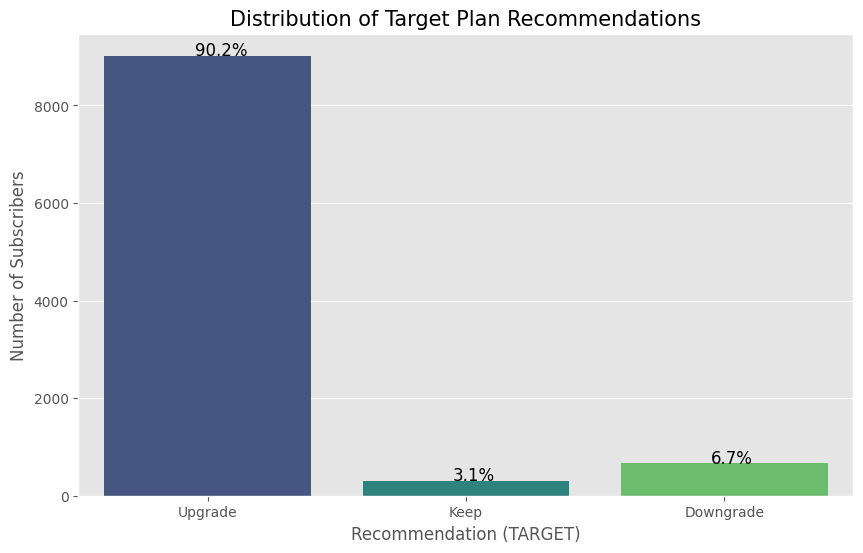

Summary of Target Distribution:
TARGET
Upgrade      9019
Downgrade     671
Keep          305
Name: count, dtype: int64

Percentage Distribution (%):
TARGET
Upgrade      90.24
Downgrade     6.71
Keep          3.05
Name: proportion, dtype: float64


In [104]:
import matplotlib.pyplot as plt
import seaborn as sns
target_order = ['Upgrade', 'Keep', 'Downgrade']
plt.figure(figsize=(10, 6))
sns.countplot(data=customer, x='TARGET', palette='viridis', order=target_order)
total = len(customer)
for p in plt.gca().patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height()
    plt.annotate(percentage, (x, y), size = 12)
plt.title('Distribution of Target Plan Recommendations', fontsize=15)
plt.xlabel('Recommendation (TARGET)', fontsize=12)
plt.ylabel('Number of Subscribers', fontsize=12)
plt.show()
print("Summary of Target Distribution:")
print(customer['TARGET'].value_counts())
print("\nPercentage Distribution (%):")
print((customer['TARGET'].value_counts(normalize=True) * 100).round(2))

---
## Step 5 — Train & Compare Models

### Objective
Train multiple classifiers and understand the tradeoffs between them.

### Why This Step Matters
No single model is always best. A good data scientist knows when to use a simple interpretable model versus a complex one — and can justify that choice to a non-technical business stakeholder.

### Models To Train

| Model | Why |
|-------|-----|
| **Logistic Regression** | Your baseline — fast, interpretable, good for linear relationships |
| **Random Forest** | Handles non-linearity and feature interactions well |
| **Gradient Boosting** | Typically stronger performance but slower to train |

### Rules
- Use the same train/test/val split for all models `random_state=42`
- Print the Classification Report for each model
- Note any class where the model performs poorly and explain why in a markdown cell


In [105]:
features = ['PRICE_PLAN_PRICE', 'avg_monthly_rev', 'addon_ratio', 'tenure_days', 'price_to_quota_ratio']
cat_features = ['TECHNOLOGY_TYPE', 'CUSTOMER_CLASS', 'GENDER']
for col in cat_features:
    if col in customer.columns:
        features.append(col)
model_data = customer.dropna(subset=['TARGET'])
X = model_data[features].copy()
y = model_data['TARGET']
X = pd.get_dummies(X, columns=[c for c in cat_features if c in X.columns], drop_first=True)
X = X.fillna(X.median(numeric_only=True))
print(f"Feature matrix prepared with shape: {X.shape}")

Feature matrix prepared with shape: (9995, 16)


In [106]:
import numpy as np
num_cols = X.select_dtypes(include=[np.number]).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())
cat_cols = X.select_dtypes(exclude=[np.number]).columns
X[cat_cols] = X[cat_cols].fillna('Unknown')
print("--- Missing Values Check After Imputation ---")
print(X.isnull().sum())

--- Missing Values Check After Imputation ---
PRICE_PLAN_PRICE        0
avg_monthly_rev         0
addon_ratio             0
tenure_days             0
price_to_quota_ratio    0
TECHNOLOGY_TYPE_ESL     0
TECHNOLOGY_TYPE_GPON    0
TECHNOLOGY_TYPE_SV      0
TECHNOLOGY_TYPE_VDSL    0
CUSTOMER_CLASS_A+       0
CUSTOMER_CLASS_B        0
CUSTOMER_CLASS_B+       0
CUSTOMER_CLASS_C        0
CUSTOMER_CLASS_C+       0
CUSTOMER_CLASS_D        0
GENDER_male             0
dtype: int64


In [107]:
print(f"Final feature matrix shape: {X.shape}")
print("\nFinal list of features used for training:")
for i, col in enumerate(X.columns, 1):
    print(f"{i}. {col}")

Final feature matrix shape: (9995, 16)

Final list of features used for training:
1. PRICE_PLAN_PRICE
2. avg_monthly_rev
3. addon_ratio
4. tenure_days
5. price_to_quota_ratio
6. TECHNOLOGY_TYPE_ESL
7. TECHNOLOGY_TYPE_GPON
8. TECHNOLOGY_TYPE_SV
9. TECHNOLOGY_TYPE_VDSL
10. CUSTOMER_CLASS_A+
11. CUSTOMER_CLASS_B
12. CUSTOMER_CLASS_B+
13. CUSTOMER_CLASS_C
14. CUSTOMER_CLASS_C+
15. CUSTOMER_CLASS_D
16. GENDER_male


In [108]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
print(f"Training set shape:   {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape:       {X_test.shape}")

Training set shape:   (6996, 16)
Validation set shape: (1499, 16)
Test set shape:       (1500, 16)


In [109]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
lr_model = LogisticRegression(random_state=42, max_iter=1000, multi_class='multinomial')
lr_model.fit(X_train_scaled, y_train)
y_val_pred_lr = lr_model.predict(X_val_scaled)

print("--- Logistic Regression (Validation Set - Real Data) ---")
print(classification_report(y_val, y_val_pred_lr))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


--- Logistic Regression (Validation Set - Real Data) ---
              precision    recall  f1-score   support

   Downgrade       0.94      0.67      0.78       100
        Keep       1.00      0.02      0.04        46
     Upgrade       0.95      1.00      0.97      1353

    accuracy                           0.95      1499
   macro avg       0.96      0.56      0.60      1499
weighted avg       0.95      0.95      0.93      1499



In [110]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
y_val_pred_rf = rf_model.predict(X_val)
print("--- Random Forest (Validation Set - Real Data) ---")
print(classification_report(y_val, y_val_pred_rf))

--- Random Forest (Validation Set - Real Data) ---
              precision    recall  f1-score   support

   Downgrade       0.99      1.00      1.00       100
        Keep       0.97      0.80      0.88        46
     Upgrade       0.99      1.00      1.00      1353

    accuracy                           0.99      1499
   macro avg       0.99      0.93      0.96      1499
weighted avg       0.99      0.99      0.99      1499



In [111]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
y_val_pred_gb = gb_model.predict(X_val)
print("--- Gradient Boosting (Validation Set - Real Data) ---")
print(classification_report(y_val, y_val_pred_gb))

--- Gradient Boosting (Validation Set - Real Data) ---
              precision    recall  f1-score   support

   Downgrade       0.99      1.00      1.00       100
        Keep       1.00      0.91      0.95        46
     Upgrade       1.00      1.00      1.00      1353

    accuracy                           1.00      1499
   macro avg       1.00      0.97      0.98      1499
weighted avg       1.00      1.00      1.00      1499



---
## Step 6 — Evaluate

### Objective
Measure model performance beyond just accuracy.


In [112]:
from sklearn.metrics import accuracy_score, f1_score
models = {
    "Logistic Regression": (lr_model, X_val_scaled),
    "Random Forest": (rf_model, X_val),
    "Gradient Boosting": (gb_model, X_val)
}
results = []
for name, (model, data) in models.items():
    preds = model.predict(data)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, preds),
        "F1-Score (Weighted)": f1_score(y_val, preds, average='weighted')
    })
comparison_df = pd.DataFrame(results)
print("--- Final Model Comparison (Real Data) ---")
display(comparison_df.sort_values(by='Accuracy', ascending=False))

--- Final Model Comparison (Real Data) ---


,Model,Accuracy,F1-Score (Weighted)
2,Gradient Boosting,0.997332,0.997274
1,Random Forest,0.993329,0.993021
0,Logistic Regression,0.945964,0.930210


---
## Step 7 — Business Impact

### Objective
Translate model predictions into actionable business recommendations.



In [113]:
X_final = customer[features].copy()
X_final = pd.get_dummies(X_final, columns=[c for c in cat_features if c in X_final.columns], drop_first=True)
for col in X_train.columns:
    if col not in X_final.columns:
        X_final[col] = 0
X_final = X_final[X_train.columns]
X_final = X_final.fillna(X_final.median())
customer['PREDICTED_TARGET'] = gb_model.predict(X_final)
print("--- Final Recommendation Summary ---")
print(customer['PREDICTED_TARGET'].value_counts())
print("\nSample Recommendations:")
display(customer[['SUBSCRIBER_ID#', 'PRICE_PLAN_PRICE', 'avg_monthly_rev', 'PREDICTED_TARGET']].head())

--- Final Recommendation Summary ---
PREDICTED_TARGET
Upgrade      9023
Downgrade     670
Keep          302
Name: count, dtype: int64

Sample Recommendations:


,SUBSCRIBER_ID#,PRICE_PLAN_PRICE,avg_monthly_rev,PREDICTED_TARGET
0,2207712503,210.0,441.629630,Upgrade
1,2206313482,210.0,696.296296,Upgrade
2,132691373,290.0,595.000000,Upgrade
3,56271964,210.0,1038.965517,Upgrade
4,54677049,0.0,329.375000,Downgrade


In [114]:
upgrade_count = (customer['PREDICTED_TARGET'] == 'Upgrade').sum()
potential_monthly_growth = upgrade_count * 100
print(f"Total Subscribers Recommended for Upgrade: {upgrade_count}")
print(f"Percentage of Base: {(upgrade_count/len(customer)*100):.1f}%")
print(f"Estimated Monthly Revenue Opportunity: {potential_monthly_growth:,} EGP")

Total Subscribers Recommended for Upgrade: 9023
Percentage of Base: 90.3%
Estimated Monthly Revenue Opportunity: 902,300 EGP


--- Profile of Upgrade Candidates ---


,PRICE_PLAN_PRICE,avg_monthly_rev,addon_ratio,tenure_days
count,9023.000000,9023.000000,9023.000000,9023.000000
mean,259.481326,512.700940,0.028968,1688.787210
std,125.697752,342.923545,0.044401,1210.154056
min,0.000000,10.000000,0.000000,9.000000
25%,210.000000,344.285714,0.000000,704.000000
50%,210.000000,435.833333,0.014344,1545.000000
75%,290.000000,574.913793,0.033069,2416.000000
max,5830.000000,13500.689655,0.500000,7738.000000


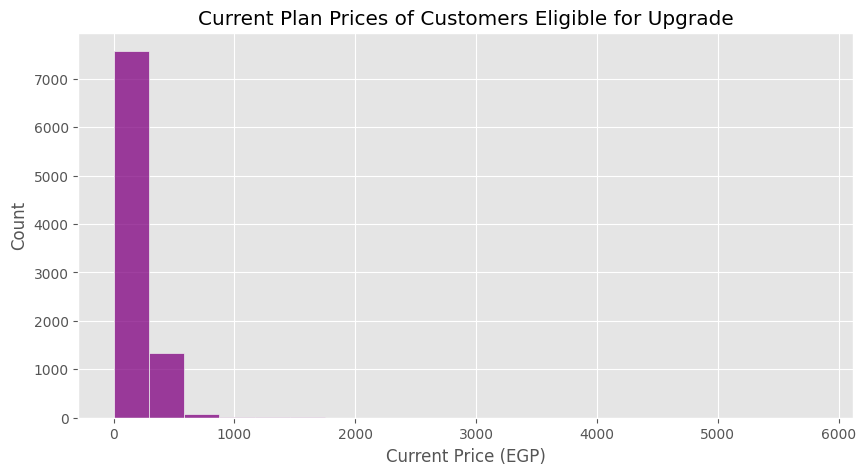

In [115]:
upgrade_candidates = customer[customer['PREDICTED_TARGET'] == 'Upgrade']
print("--- Profile of Upgrade Candidates ---")
display(upgrade_candidates[['PRICE_PLAN_PRICE', 'avg_monthly_rev', 'addon_ratio', 'tenure_days']].describe())
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.histplot(upgrade_candidates['PRICE_PLAN_PRICE'], color='purple', bins=20)
plt.title('Current Plan Prices of Customers Eligible for Upgrade')
plt.xlabel('Current Price (EGP)')
plt.show()